# PHASE 1 - Exploratory Data Analysis

This notebook inspects the hourly bike-sharing dataset and visualizes demand patterns. No model is trained in this phase.

The target is `cnt` (total rentals). The raw data is loaded without fitting a scaler or using future target values as features; lag and rolling features belong to PHASE 2.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)

data_candidates = [
    Path("data/raw/hour.csv"),
    Path("../data/raw/hour.csv"),
]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Place the dataset at data/raw/hour.csv before running this notebook.")

df = pd.read_csv(data_path)
df["dteday"] = pd.to_datetime(df["dteday"], errors="raise")
df = df.sort_values(["dteday", "hr"]).reset_index(drop=True)

print(f"Loaded: {data_path}")
print(f"Shape: {df.shape}")
df.head()

Loaded: ..\data\raw\hour.csv
Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Data quality and schema

In [8]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("Missing values:")
display(df.isna().sum().to_frame("missing_count"))

print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Date range: {df['dteday'].min().date()} to {df['dteday'].max().date()}")
print("Target summary (cnt):")
display(df["cnt"].describe().to_frame("cnt"))

Data types:


,dtype
instant,int64
dteday,datetime64[us]
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


Missing values:


,missing_count
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


Duplicate rows: 0
Date range: 2011-01-01 to 2012-12-31
Target summary (cnt):


,cnt
count,17379.000000
mean,189.463088
std,181.387599
min,1.000000
25%,40.000000
50%,142.000000
75%,281.000000
max,977.000000


In [9]:
# Confirm that the supplied calendar columns agree with the parsed date.
calendar_check = pd.DataFrame({
    "weekday_column": df["weekday"],
    "weekday_from_date": df["dteday"].dt.weekday,
    "month_column": df["mnth"],
    "month_from_date": df["dteday"].dt.month,
})
display(calendar_check.head())
print("weekday mismatches:", (calendar_check["weekday_column"] != calendar_check["weekday_from_date"]).sum())
print("month mismatches:", (calendar_check["month_column"] != calendar_check["month_from_date"]).sum())

,weekday_column,weekday_from_date,month_column,month_from_date
0,6,5,1,1
1,6,5,1,1
2,6,5,1,1
3,6,5,1,1
4,6,5,1,1


weekday mismatches: 17379
month mismatches: 0


## Demand patterns

In [10]:
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
season_names = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
weather_names = {1: "Clear", 2: "Mist/Cloudy", 3: "Light rain/snow", 4: "Heavy rain/snow"}

df["weekday_name"] = df["weekday"].map(dict(enumerate(weekday_names)))
df["season_name"] = df["season"].map(season_names)
df["weather_name"] = df["weathersit"].map(weather_names)

summary_tables = {
    "hour": df.groupby("hr", as_index=False)["cnt"].mean(),
    "weekday": df.groupby(["weekday", "weekday_name"], as_index=False)["cnt"].mean(),
    "month": df.groupby("mnth", as_index=False)["cnt"].mean(),
    "season": df.groupby(["season", "season_name"], as_index=False)["cnt"].mean(),
    "workingday": df.groupby("workingday", as_index=False)["cnt"].mean(),
    "weather": df.groupby(["weathersit", "weather_name"], as_index=False)["cnt"].mean(),
}
for name, table in summary_tables.items():
    print(f"Average demand by {name}:")
    display(table)

Average demand by hour:


,hr,cnt
0,0,53.898072
1,1,33.375691
2,2,22.869930
3,3,11.727403
4,4,6.352941
5,5,19.889819
6,6,76.044138
7,7,212.064649
8,8,359.011004
9,9,219.309491


Average demand by weekday:


,weekday,weekday_name,cnt
0,0,Mon,177.468825
1,1,Tue,183.744655
2,2,Wed,191.238891
3,3,Thu,191.130505
4,4,Fri,196.436665
5,5,Sat,196.135907
6,6,Sun,190.209793


Average demand by month:


...

,season,season_name,cnt
0,1,Spring,111.114569
1,2,Summer,208.344069
2,3,Fall,236.016237
3,4,Winter,198.868856


Average demand by workingday:


,workingday,cnt
0,0,181.405332
1,1,193.207754


Average demand by weather:


,weathersit,weather_name,cnt
0,1,Clear,204.869272
1,2,Mist/Cloudy,175.165493
2,3,Light rain/snow,111.579281
3,4,Heavy rain/snow,74.333333


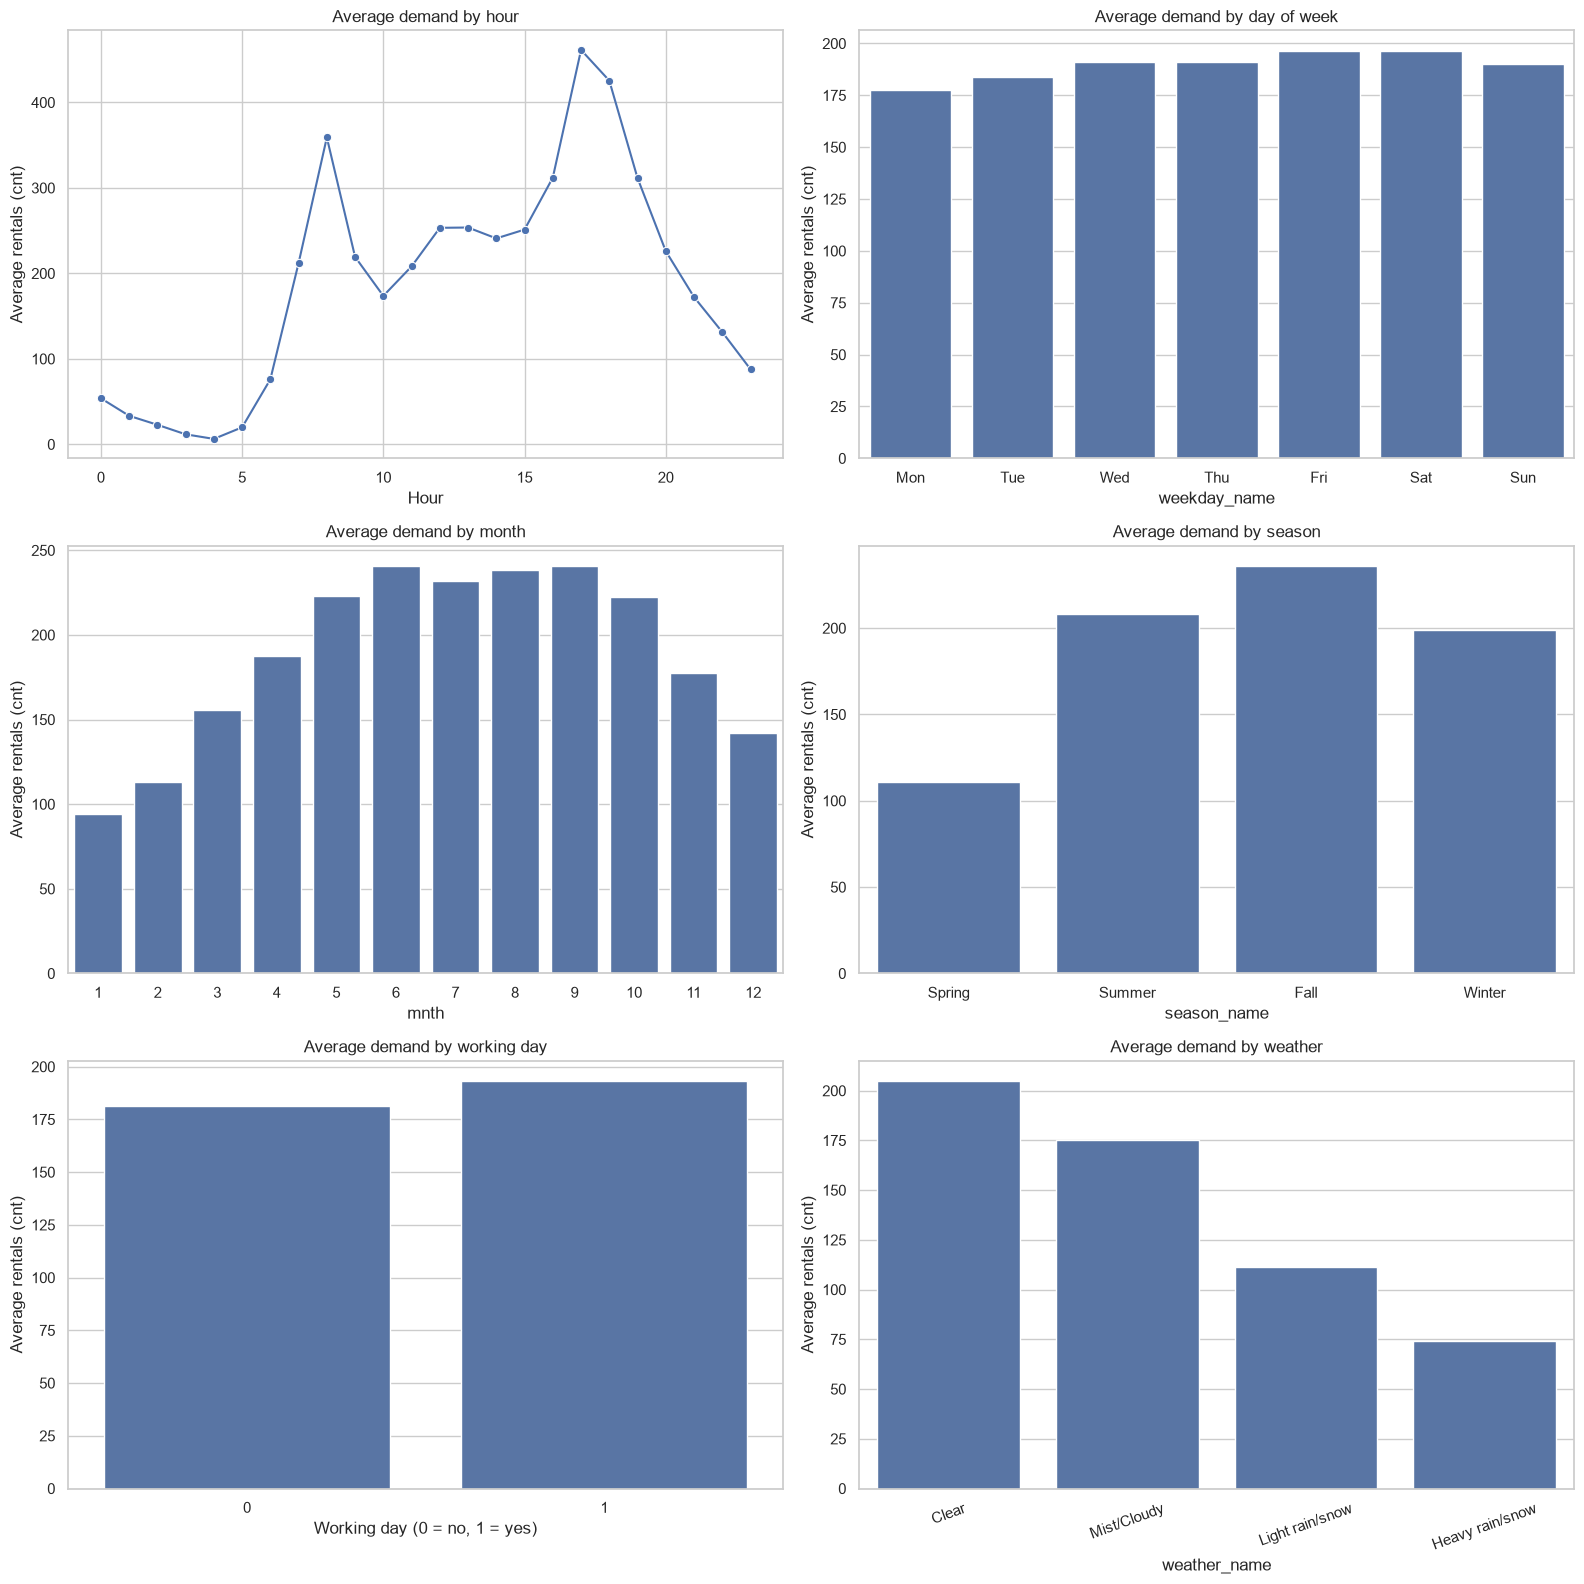

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))

sns.lineplot(data=summary_tables["hour"], x="hr", y="cnt", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Average demand by hour")
axes[0, 0].set_xlabel("Hour")

sns.barplot(data=summary_tables["weekday"], x="weekday_name", y="cnt", order=weekday_names, ax=axes[0, 1])
axes[0, 1].set_title("Average demand by day of week")

sns.barplot(data=summary_tables["month"], x="mnth", y="cnt", ax=axes[1, 0])
axes[1, 0].set_title("Average demand by month")

sns.barplot(data=summary_tables["season"], x="season_name", y="cnt", ax=axes[1, 1])
axes[1, 1].set_title("Average demand by season")

sns.barplot(data=summary_tables["workingday"], x="workingday", y="cnt", ax=axes[2, 0])
axes[2, 0].set_title("Average demand by working day")
axes[2, 0].set_xlabel("Working day (0 = no, 1 = yes)")

sns.barplot(data=summary_tables["weather"], x="weather_name", y="cnt", ax=axes[2, 1])
axes[2, 1].set_title("Average demand by weather")
axes[2, 1].tick_params(axis="x", rotation=20)

for axis in axes.flat:
    axis.set_ylabel("Average rentals (cnt)")

plt.tight_layout()
plt.show()

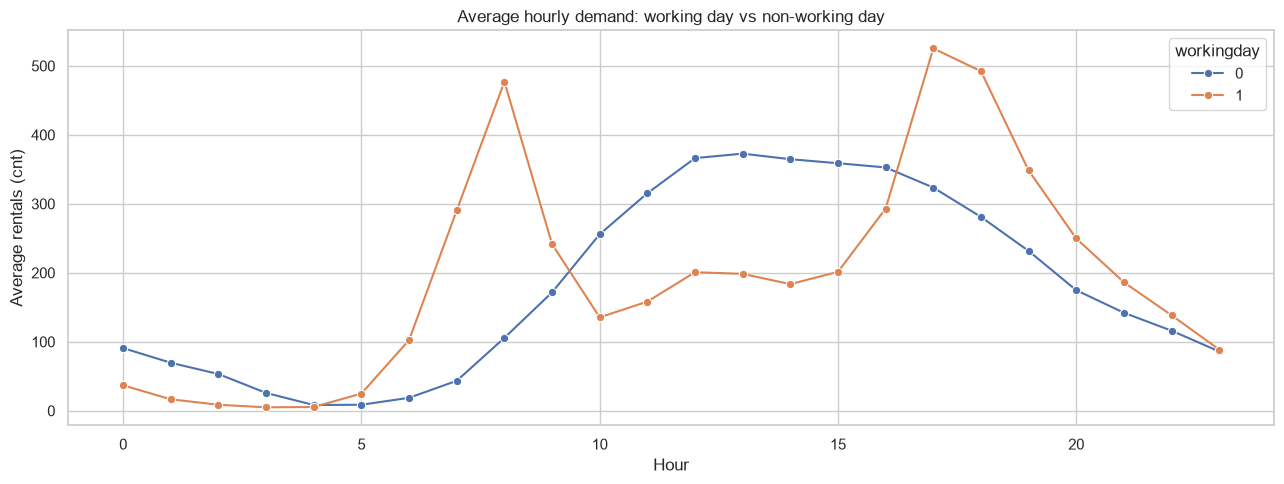

In [12]:
# A compact view of hourly demand split by working-day status.
plt.figure(figsize=(13, 5))
sns.lineplot(data=df, x="hr", y="cnt", hue="workingday", estimator="mean", errorbar=None, marker="o")
plt.title("Average hourly demand: working day vs non-working day")
plt.xlabel("Hour")
plt.ylabel("Average rentals (cnt)")
plt.tight_layout()
plt.show()

## Phase 1 conclusion

Use the printed quality checks and charts to record the observed patterns. Model training is intentionally excluded. Before PHASE 2, confirm that the parsed date, target column, and any quality issues are understood.